In [1]:
!pip install diffusers

  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ------ --------------------------------- 0.8/5.0 MB 11.2 MB/s eta 0:00:01
   ------------ --------------------------- 1.6/5.0 MB 5.2 MB/s eta 0:00:01
   ------------------ --------------------- 2.4/5.0 MB 4.6 MB/s eta 0:00:01
   ------------------------- -------------- 3.1/5.0 MB 4.4 MB/s eta 0:00:01
   ------------------------------- -------- 3.9/5.0 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------  5.0/5.0 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 4.1 MB/s  0:00:01
Using cached zipp-3.23.0-py3-none-any.whl (10 kB)

   ---------------------------------------- 0/3 [zipp]
   ------------- -------------------------- 1/3 [importlib_metadata]
   ------------- -------------------------- 1/3 [importlib_metadata]
   -------------------------- ------------- 2/3 [diffusers]
   -------------------------- -----

In [3]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained("prompthero/openjourney").to("cuda")

image = pipe("Batman").images[0]

image.show()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

C:\Users\Piyush\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Piyush\.cache\huggingface\hub\models--prompthero--openjourney. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Piyush\.cache\huggingface\hub\models--prompthero--openjourney\snapshots\f4572661b028c732b2b97c8fbdc32fa5db3afe03\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Piyush\.cache\huggingface\hub\models--prompthero--openjourney\snapshots\f4572661b028c732b2b97c8fbdc32fa5db3afe03\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

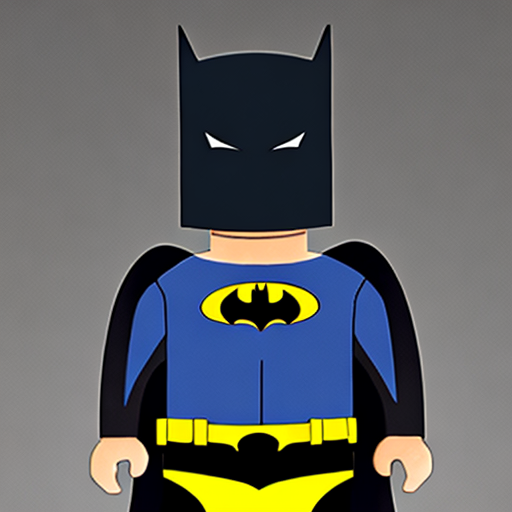

In [5]:
from IPython.display import display
display(image)

In [6]:
print(image.size)

(512, 512)


In [ ]:
import torch
from diffusers import UNet2DConditionModel, DDPMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"

unet = UNet2DConditionModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="unet"
).to(device)

scheduler = DDPMScheduler.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="scheduler"
)

latents = torch.randn((1, 4, 64, 64)).to(device)

for t in scheduler.timesteps:
    with torch.no_grad():
        noise_pred = unet(latents, t).sample
    latents = scheduler.step(noise_pred, t, latents).prev_sample